# Exercise 5 — Text Classification with Transformers
### Sarcasm Detector

---

## The Problem

A news aggregation platform wants to automatically flag sarcastic headlines
before surfacing them in serious news feeds — sarcastic content mixed into
factual news erodes reader trust.

You are given a dataset of real news headlines labeled as sarcastic or not.
Build a binary text classifier using a pretrained transformer.

---

## The Data

```python
!pip install transformers opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection")
```

A JSON file where each line is a headline with an `is_sarcastic` label (0 or 1)
and the source `article_link`. The column you need is `headline`.

⚠️ **One thing worth knowing:** this is a large dataset. If training is slow,
start with a subset to verify your pipeline works before scaling up.

---

## What You Need to Deliver

A working Colab notebook that contains:

1. **A fine-tuned transformer model** (from HuggingFace) that classifies
   headlines as sarcastic or not
2. **A clear statement** of which pretrained model you used, which weights
   you froze, and what classification head you added — and why
3. **A training report** — loss and accuracy curves for train and validation
4. **A test accuracy score**
5. **A live inference demo** — given any headline string,
   the model returns sarcastic or not sarcastic

You must use `AutoTokenizer` and `AutoModel` from the `transformers` library.
The model choice, head architecture, and training decisions are yours.

---

In [1]:
!git clone https://github.com/Ibraheem-Al-hafith/classification_hub.git
%cd classification_hub

Cloning into 'classification_hub'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 56 (delta 25), reused 38 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 1.41 MiB | 8.29 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/kaggle/working/classification_hub


In [2]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm

def seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    print(f"Random seed set to: {seed}")

class config:
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"
    batch_size = 32 # This batch_size is not directly used by dataloader_configs
    num_workers = 2
    learning_rate = 0.001
    num_epochs = 2
    dataset_name = "rmisra/news-headlines-dataset-for-sarcasm-detection"
    scaler = "standard" # options: "standard" , "minmax" , "robust"
    dataloader_configs = {
        "batch_size": 32, # Reduced batch size to mitigate OutOfMemoryError
        "num_workers": 2,
        "pin_memory": True
    }

seed_everything(config.seed)
print(f"Device set to: {config.device}")

Random seed set to: 42
Device set to: cuda


In [5]:
from utilities import download_kaggle_dataset
data_path = Path("/kaggle/input/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection")

In [6]:
import json

with open(data_path / "Sarcasm_Headlines_Dataset.json", 'r') as f:
    data = [json.loads(line) for line in f]
print(len(data))
with open(data_path / "Sarcasm_Headlines_Dataset_v2.json", 'r') as f:
    data.extend([json.loads(line) for line in f])
print(len(data))
df = pd.DataFrame(data).drop(columns="article_link")
df.rename(columns={"headline": "text", "is_sarcastic": "label"}, inplace=True)
df.head()

26709
55328


,text,label
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


# Dont forget to DOWNSAMPLING

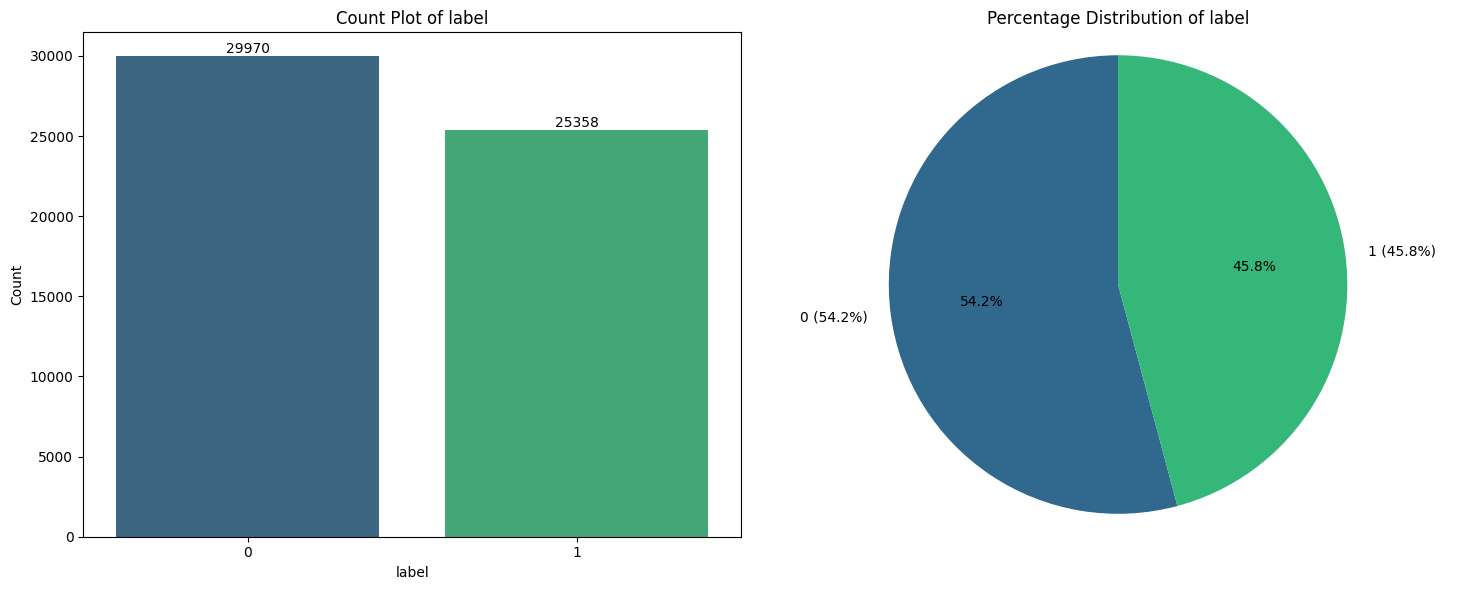

In [7]:
def plot_categorical_distribution(df, column_name):
    """
    Plots a count plot and a pie chart with percentages for a given categorical column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the categorical column to plot.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Count Plot
    sns.countplot(x=column_name, data=df, ax=axes[0], hue=column_name, palette='viridis', legend=False)
    axes[0].set_title(f'Count Plot of {column_name}')
    axes[0].set_xlabel(column_name)
    axes[0].set_ylabel('Count')

    # Add counts on top of bars
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

    # Pie Chart
    counts = df[column_name].value_counts()
    percentages = counts / len(df) * 100
    labels = [f'{idx} ({val:.1f}%)' for idx, val in zip(counts.index, percentages)]
    axes[1].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(counts)))
    axes[1].set_title(f'Percentage Distribution of {column_name}')
    axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

    plt.tight_layout()
    plt.show()

# Apply the function to the target column
plot_categorical_distribution(df, "label")

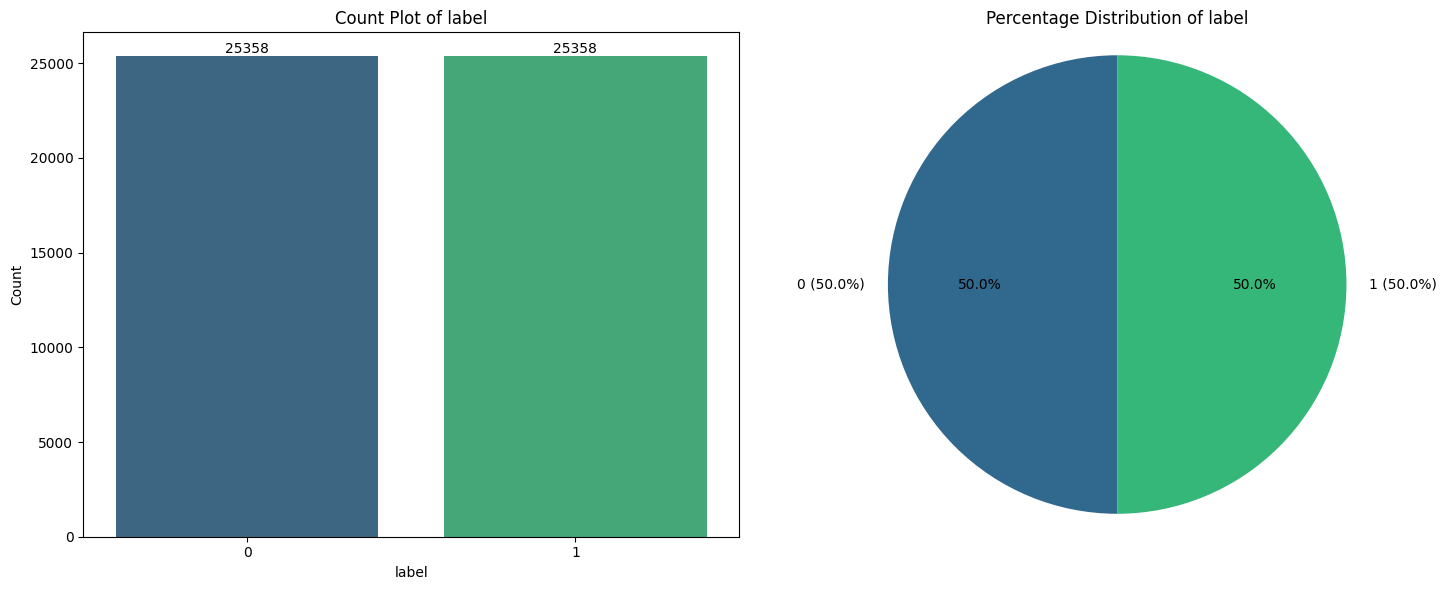

In [8]:
# Downsampling the majority class
minority_class = df[df['label'] == 1]
majority_class = df[df['label'] == 0]
downsampled_majority = majority_class.sample(n=len(minority_class), random_state=config.seed)
df = pd.concat([downsampled_majority, minority_class])
df.reset_index(drop=True, inplace=True)
plot_categorical_distribution(df, "label")

In [9]:
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments,
    DataCollatorWithPadding
)

train, val_test = train_test_split(df, test_size=0.3, random_state=config.seed, stratify=df['label'])
val, test = train_test_split(val_test, test_size=0.5, random_state=config.seed, stratify=val_test["label"])

train_dataset = Dataset.from_pandas(train)
val_dataset = Dataset.from_pandas(val)
test_dataset = Dataset.from_pandas(test)

# --- 4. Load DistilBERT Tokenizer --- 
MODEL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

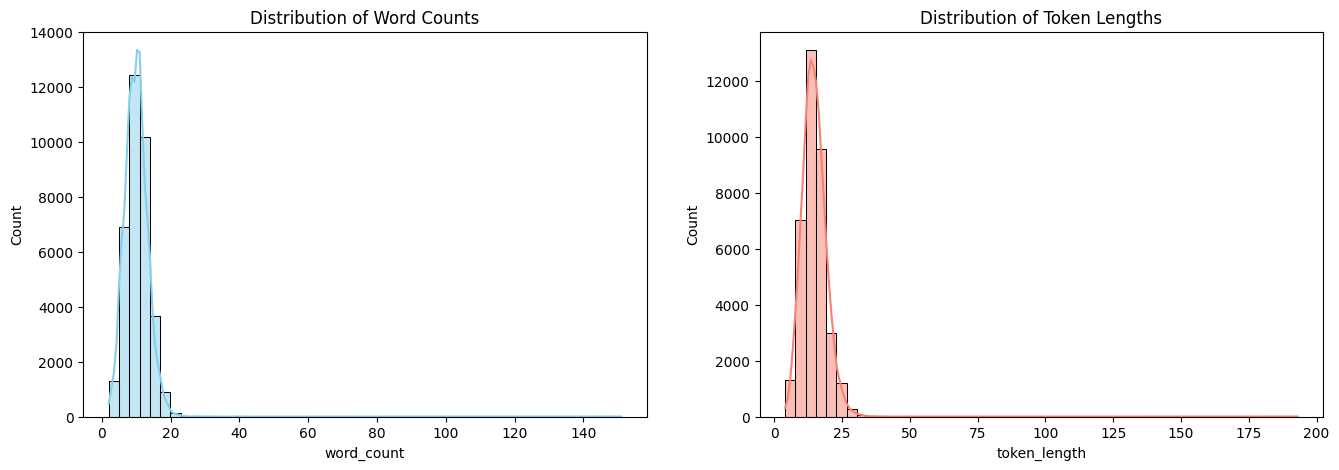

95th percentile of token length: 22.0
99th percentile of token length: 26.0
Absolute max token length: 193


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate word counts and token counts for EDA
train['word_count'] = train['text'].apply(lambda x: len(x.split()))
# Get token lengths using the actual tokenizer
train['token_length'] = train['text'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True)))

# Visualize distributions
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(train['word_count'], bins=50, ax=ax[0], color='skyblue', kde=True)
ax[0].set_title('Distribution of Word Counts')

sns.histplot(train['token_length'], bins=50, ax=ax[1], color='salmon', kde=True)
ax[1].set_title('Distribution of Token Lengths')

plt.show()

# Calculate statistics for informed decision
p95 = train['token_length'].quantile(0.95)
p99 = train['token_length'].quantile(0.99)
max_len = train['token_length'].max()

print(f"95th percentile of token length: {p95}")
print(f"99th percentile of token length: {p99}")
print(f"Absolute max token length: {max_len}")

In [11]:
def tokenize_mapping(batch):
    # Optimized max_length based on EDA (99th percentile was 26)
    return tokenizer(batch["text"], truncation=True, max_length=64, padding="max_length")

# Map tokenization over datasets efficiently in batches
train_dataset = train_dataset.map(tokenize_mapping, batched=True, remove_columns=['text'])
val_dataset = val_dataset.map(tokenize_mapping, batched=True, remove_columns=['text'])
test_dataset = test_dataset.map(tokenize_mapping, batched=True, remove_columns=['text'])

Map:   0%|          | 0/35501 [00:00<?, ? examples/s]

Map:   0%|          | 0/7607 [00:00<?, ? examples/s]

Map:   0%|          | 0/7608 [00:00<?, ? examples/s]

In [12]:
# Dynamically pads batch samples to the maximum length seen inside each batch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_loader = DataLoader(train_dataset, **config.dataloader_configs, collate_fn=data_collator)
val_loader = DataLoader(val_dataset, **config.dataloader_configs, collate_fn=data_collator)
test_loader = DataLoader(test_dataset, **config.dataloader_configs, collate_fn=data_collator)

In [13]:
# Modelling
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(config.device)

# Freeze the model parameters except the last block and the classifier
for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [14]:
!pip install evaluate --quiet
import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00


In [ ]:
from transformers import TrainingArguments, Trainer

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=config.dataloader_configs['batch_size'],
    per_device_eval_batch_size=config.dataloader_configs['batch_size'],
    learning_rate=config.learning_rate,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none",
    seed=config.seed,
    fp16=True,
    #gradient_accumulation_steps=2,
    gradient_checkpointing=True
)

# Initialize the Hugging Face Trainer with compute_metrics
hf_trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

# Start training
hf_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss


In [16]:
hf_trainer.evaluate()

NameError: name 'hf_trainer' is not defined